In [186]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [187]:

df = pd.read_csv('loan risk assessment_dataset.csv')

In [188]:
df

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


In [189]:
df.shape

(32581, 12)

In [190]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

In [191]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [192]:
df['loan_intent'].value_counts()

loan_intent
EDUCATION            6453
MEDICAL              6071
VENTURE              5719
PERSONAL             5521
DEBTCONSOLIDATION    5212
HOMEIMPROVEMENT      3605
Name: count, dtype: int64

In [193]:
df['loan_grade'].value_counts()

loan_grade
A    10777
B    10451
C     6458
D     3626
E      964
F      241
G       64
Name: count, dtype: int64

In [194]:
df.describe().T    #Use dot 'T' means to Remove complex values and give absolute values only.

,count,mean,std,min,25%,50%,75%,max
person_age,32581.0,27.734600,6.348078,20.00,23.00,26.00,30.00,144.00
person_income,32581.0,66074.848470,61983.119168,4000.00,38500.00,55000.00,79200.00,6000000.00
person_emp_length,31686.0,4.789686,4.142630,0.00,2.00,4.00,7.00,123.00
loan_amnt,32581.0,9589.371106,6322.086646,500.00,5000.00,8000.00,12200.00,35000.00
loan_int_rate,29465.0,11.011695,3.240459,5.42,7.90,10.99,13.47,23.22
loan_status,32581.0,0.218164,0.413006,0.00,0.00,0.00,0.00,1.00
loan_percent_income,32581.0,0.170203,0.106782,0.00,0.09,0.15,0.23,0.83
cb_person_cred_hist_length,32581.0,5.804211,4.055001,2.00,3.00,4.00,8.00,30.00


In [195]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [196]:
df.fillna({'person_emp_length': 0,
               'loan_int_rate': 0})

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


In [197]:
## Find all numerical columns of the given dataframe:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
print(numerical_cols)

for column in numerical_cols:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[column] < Q1 - 1.5 * IQR) | (df[column] > Q3 + 1.5 * IQR)]
    print(f"\n {column}: {len(outliers)} outliers")
    

Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_cred_hist_length'],
      dtype='object')

 person_age: 1494 outliers

 person_income: 1484 outliers

 person_emp_length: 853 outliers

 loan_amnt: 1689 outliers

 loan_int_rate: 6 outliers

 loan_status: 7108 outliers

 loan_percent_income: 651 outliers

 cb_person_cred_hist_length: 1142 outliers


In [198]:
#(i) detect outliers of person_income using IQR method;
def detect_outliers_IQR(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    return outliers, Q1, Q3, lower_bound, upper_bound

outliers, Q1, Q3, lower_bound, upper_bound = detect_outliers_IQR(df, 'person_income')

print(f'Number of outliers: {len(outliers)}')

Number of outliers: 1484


In [199]:
df_cleaned = df[(df['person_income'] >= lower_bound) & (df['person_income'] <= upper_bound)]

In [200]:
# Again, checking these outliers;
def detect_outliers_IQR(df_cleaned, column):
    Q1 = df_cleaned[column].quantile(0.25)
    Q3 = df_cleaned[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_cleaned[(df_cleaned[column] < lower_bound) | (df_cleaned[column] > upper_bound)]

    return outliers, Q1, Q3, lower_bound, upper_bound

outliers, Q1, Q3, lower_bound, upper_bound = detect_outliers_IQR(df_cleaned, 'person_income')

print(f'Number of outliers: {len(outliers)}')


Number of outliers: 372


In [201]:
df_cleaned = df[(df['person_income'] >= lower_bound) & (df['person_income'] <= upper_bound)]

In [202]:
#Agan check outliers after cleaning:
def detect_outliers_IQR(df_cleaned, column):
    Q1 = df_cleaned[column].quantile(0.25)
    Q3 = df_cleaned[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_cleaned[(df_cleaned[column] < lower_bound) | (df_cleaned[column] > upper_bound)]

    return outliers, Q1, Q3, lower_bound, upper_bound

outliers, Q1, Q3, lower_bound, upper_bound = detect_outliers_IQR(df_cleaned, 'person_income')

print(f'Number of outliers: {len(outliers)}')

Number of outliers: 171


In [203]:
df_cleaned = df[(df['person_income'] >= lower_bound) & (df['person_income'] <= upper_bound)]

In [204]:
#Again check outliers after cleaning:
def detect_outliers_IQR(df_cleaned, column):
    Q1 = df_cleaned[column].quantile(0.25)
    Q3 = df_cleaned[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_cleaned[(df_cleaned[column] < lower_bound) | (df_cleaned[column] > upper_bound)]

    return outliers, Q1, Q3, lower_bound, upper_bound

outliers, Q1, Q3, lower_bound, upper_bound = detect_outliers_IQR(df_cleaned, 'person_income')

print(f'Number of outliers: {len(outliers)}')

Number of outliers: 3


In [205]:
df_cleaned = df[(df['person_income'] >= lower_bound) & (df['person_income'] <= upper_bound)]

In [206]:
#Again check outliers after cleaning:
def detect_outliers_IQR(df_cleaned, column):
    Q1 = df_cleaned[column].quantile(0.25)
    Q3 = df_cleaned[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_cleaned[(df_cleaned[column] < lower_bound) | (df_cleaned[column] > upper_bound)]

    return outliers, Q1, Q3, lower_bound, upper_bound

outliers, Q1, Q3, lower_bound, upper_bound = detect_outliers_IQR(df_cleaned, 'person_income')

print(f'Number of outliers: {len(outliers)}')

Number of outliers: 0


In [207]:
df_cleaned = df[(df['person_income'] >= lower_bound) & (df['person_income'] <= upper_bound)]

In [208]:
#Again check outliers after cleaning:
def detect_outliers_IQR(df_cleaned, column):
    Q1 = df_cleaned[column].quantile(0.25)
    Q3 = df_cleaned[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_cleaned[(df_cleaned[column] < lower_bound) | (df_cleaned[column] > upper_bound)]

    return outliers, Q1, Q3, lower_bound, upper_bound

outliers, Q1, Q3, lower_bound, upper_bound = detect_outliers_IQR(df_cleaned, 'person_income')

print(f'Number of outliers: {len(outliers)}')

Number of outliers: 0


In [209]:
##(ii)TO remove outliers  of loan_amnt from the dataset:
def detect_outliers_IQR(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    return outliers, Q1, Q3, lower_bound, upper_bound

outliers, Q1, Q3, lower_bound, upper_bound = detect_outliers_IQR(df, 'loan_amnt')

print(f'Number of outliers: {len(outliers)}')

Number of outliers: 1689


In [210]:

df_cleaned = df[(df['loan_amnt'] >= lower_bound) & (df['loan_amnt'] <= upper_bound)]

In [211]:
#Again check outliers after cleaning:
def detect_outliers_IQR(df_cleaned, column):
    Q1 = df_cleaned[column].quantile(0.25)
    Q3 = df_cleaned[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_cleaned[(df_cleaned[column] < lower_bound) | (df_cleaned[column] > upper_bound)]

    return outliers, Q1, Q3, lower_bound, upper_bound

outliers, Q1, Q3, lower_bound, upper_bound = detect_outliers_IQR(df_cleaned, 'loan_amnt')

print(f'Number of outliers: {len(outliers)}')

Number of outliers: 60


In [212]:
df_cleaned = df[(df['loan_amnt'] >= lower_bound) & (df['loan_amnt'] <= upper_bound)]

In [213]:
#Again check outliers after cleaning:
def detect_outliers_IQR(df_cleaned, column):
    Q1 = df_cleaned[column].quantile(0.25)
    Q3 = df_cleaned[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_cleaned[(df_cleaned[column] < lower_bound) | (df_cleaned[column] > upper_bound)]

    return outliers, Q1, Q3, lower_bound, upper_bound

outliers, Q1, Q3, lower_bound, upper_bound = detect_outliers_IQR(df_cleaned, 'loan_amnt')

print(f'Number of outliers: {len(outliers)}')

Number of outliers: 0


In [214]:
##(iii)TO remove outliers  of loan_status from the dataset:
def detect_outliers_IQR(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    return outliers, Q1, Q3, lower_bound, upper_bound

outliers, Q1, Q3, lower_bound, upper_bound = detect_outliers_IQR(df, 'loan_status')

print(f'Number of outliers: {len(outliers)}')

Number of outliers: 7108


In [215]:

df_cleaned = df[(df['loan_status'] >= lower_bound) & (df['loan_status'] <= upper_bound)]

In [216]:
#Again check outliers after cleaning:
def detect_outliers_IQR(df_cleaned, column):
    Q1 = df_cleaned[column].quantile(0.25)
    Q3 = df_cleaned[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_cleaned[(df_cleaned[column] < lower_bound) | (df_cleaned[column] > upper_bound)]

    return outliers, Q1, Q3, lower_bound, upper_bound

outliers, Q1, Q3, lower_bound, upper_bound = detect_outliers_IQR(df_cleaned, 'loan_status')

print(f'Number of outliers: {len(outliers)}')

Number of outliers: 0


In [217]:
#(iv)TO remove outliers  of loan_percent_income from the dataset:
def detect_outliers_IQR(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    return outliers, Q1, Q3, lower_bound, upper_bound

outliers, Q1, Q3, lower_bound, upper_bound = detect_outliers_IQR(df, 'loan_percent_income')

print(f'Number of outliers: {len(outliers)}')

Number of outliers: 651


In [218]:

df_cleaned = df[(df['loan_percent_income'] >= lower_bound) & (df['loan_percent_income'] <= upper_bound)]

In [219]:
#Again check outliers after cleaning:
def detect_outliers_IQR(df_cleaned, column):
    Q1 = df_cleaned[column].quantile(0.25)
    Q3 = df_cleaned[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_cleaned[(df_cleaned[column] < lower_bound) | (df_cleaned[column] > upper_bound)]

    return outliers, Q1, Q3, lower_bound, upper_bound

outliers, Q1, Q3, lower_bound, upper_bound = detect_outliers_IQR(df_cleaned, 'loan_percent_income')

print(f'Number of outliers: {len(outliers)}')

Number of outliers: 350


In [220]:
df_cleaned = df[(df['loan_percent_income'] >= lower_bound) & (df['loan_percent_income'] <= upper_bound)]

In [221]:
#Again check outliers after cleaning:
def detect_outliers_IQR(df_cleaned, column):
    Q1 = df_cleaned[column].quantile(0.25)
    Q3 = df_cleaned[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_cleaned[(df_cleaned[column] < lower_bound) | (df_cleaned[column] > upper_bound)]

    return outliers, Q1, Q3, lower_bound, upper_bound

outliers, Q1, Q3, lower_bound, upper_bound = detect_outliers_IQR(df_cleaned, 'loan_percent_income')

print(f'Number of outliers: {len(outliers)}')

Number of outliers: 0


In [222]:
#(v)TO remove outliers  of cb_person_cred_hist_length from the dataset:
def detect_outliers_IQR(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    return outliers, Q1, Q3, lower_bound, upper_bound

outliers, Q1, Q3, lower_bound, upper_bound = detect_outliers_IQR(df, 'cb_person_cred_hist_length')

print(f'Number of outliers: {len(outliers)}')

Number of outliers: 1142


In [223]:
df_cleaned = df[(df['cb_person_cred_hist_length'] >= lower_bound) & (df['cb_person_cred_hist_length'] <= upper_bound)]

In [224]:
#Again check outliers after cleaning:
def detect_outliers_IQR(df_cleaned, column):
    Q1 = df_cleaned[column].quantile(0.25)
    Q3 = df_cleaned[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_cleaned[(df_cleaned[column] < lower_bound) | (df_cleaned[column] > upper_bound)]

    return outliers, Q1, Q3, lower_bound, upper_bound

outliers, Q1, Q3, lower_bound, upper_bound = detect_outliers_IQR(df_cleaned, 'cb_person_cred_hist_length')

print(f'Number of outliers: {len(outliers)}')

Number of outliers: 0


`Correlation between 'person_income' and 'loan_amnt'`

               person_income  loan_amnt
person_income       1.000000   0.342322
loan_amnt           0.342322   1.000000


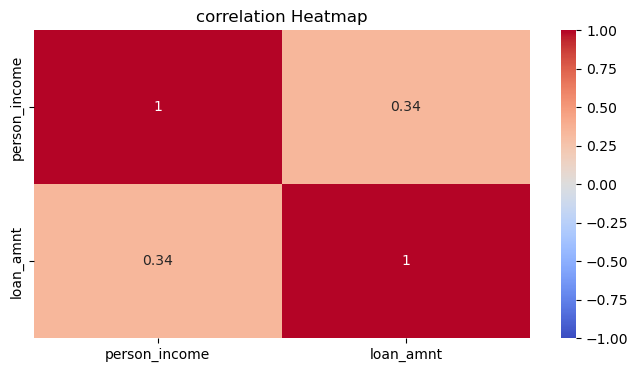

In [225]:
# correlation between 'person_income' and 'loan_amnt'

correlation_matrix = df_cleaned[['person_income','loan_amnt']].corr()
print(correlation_matrix)
plt.figure(figsize=(8,4))
sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm',vmin=-1,vmax=1)
plt.title('correlation Heatmap')
plt.show()

Credit history vs. loan status!!

loan status is a binary variable where:loan_status = 0 indicate 'No Defaulted case' and  1 indicates 'defaulted case'.

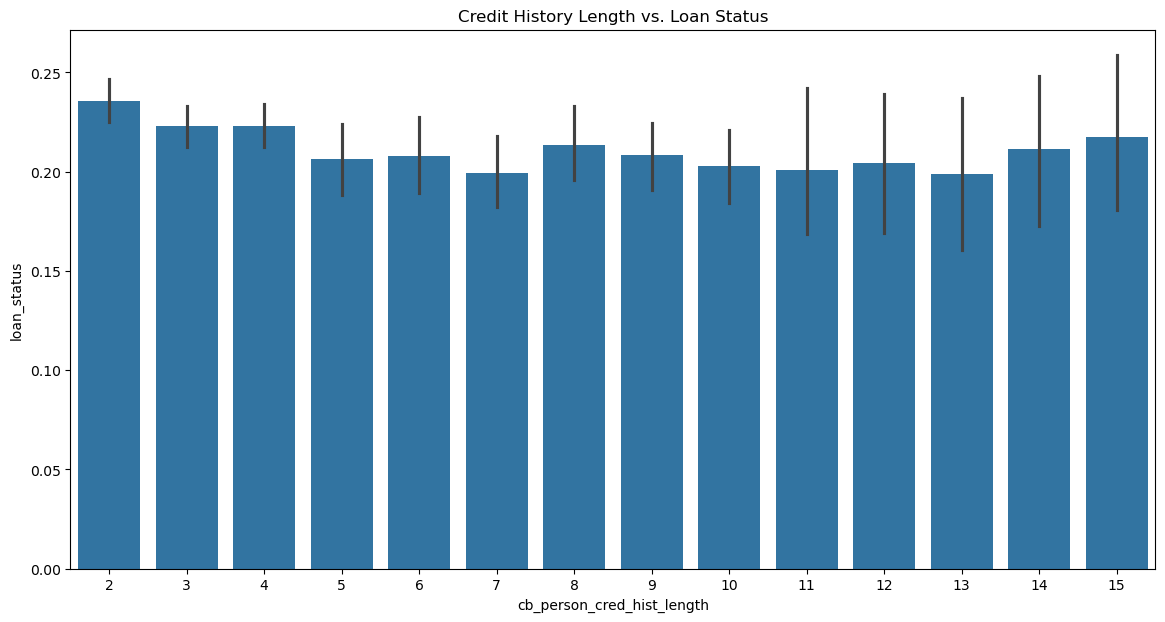

In [226]:
#Histogram of 'person_income':
plt.figure(figsize=(14, 7))
sns.barplot( x='cb_person_cred_hist_length', y='loan_status',data=df_cleaned)
plt.title('Credit History Length vs. Loan Status')
plt.show()

                            cb_person_cred_hist_length  loan_status
cb_person_cred_hist_length                    1.000000    -0.021966
loan_status                                  -0.021966     1.000000


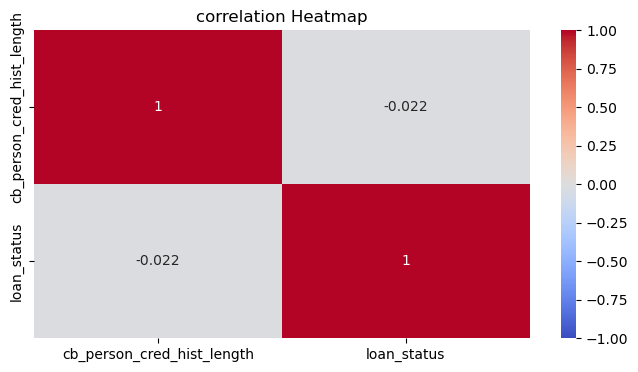

In [227]:
#correlation between 'cb_person_cred_hist_length' and 'loan_status':
correlation_matrix = df_cleaned[['cb_person_cred_hist_length','loan_status']].corr()
print(correlation_matrix)
plt.figure(figsize=(8,4))
sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm',vmin=-1,vmax=1)
plt.title('correlation Heatmap')
plt.show()

`Default rate by home ownership`

In [ ]:
# Count default status per home ownership group
Default_rate_by_home_ownership=(df_cleaned.groupby('person_home_ownership')['cb_person_default_on_file'].value_counts().unstack().fillna(0))

# Calculate percentages (row-wise)
default_percentages = Default_rate_by_home_ownership.div(Default_rate_by_home_ownership.sum(axis=1), axis=0) * 100

print(default_percentages)


cb_person_default_on_file          N          Y
person_home_ownership                          
MORTGAGE                   85.182617  14.817383
OTHER                      74.038462  25.961538
OWN                        82.859431  17.140569
RENT                       80.037831  19.962169


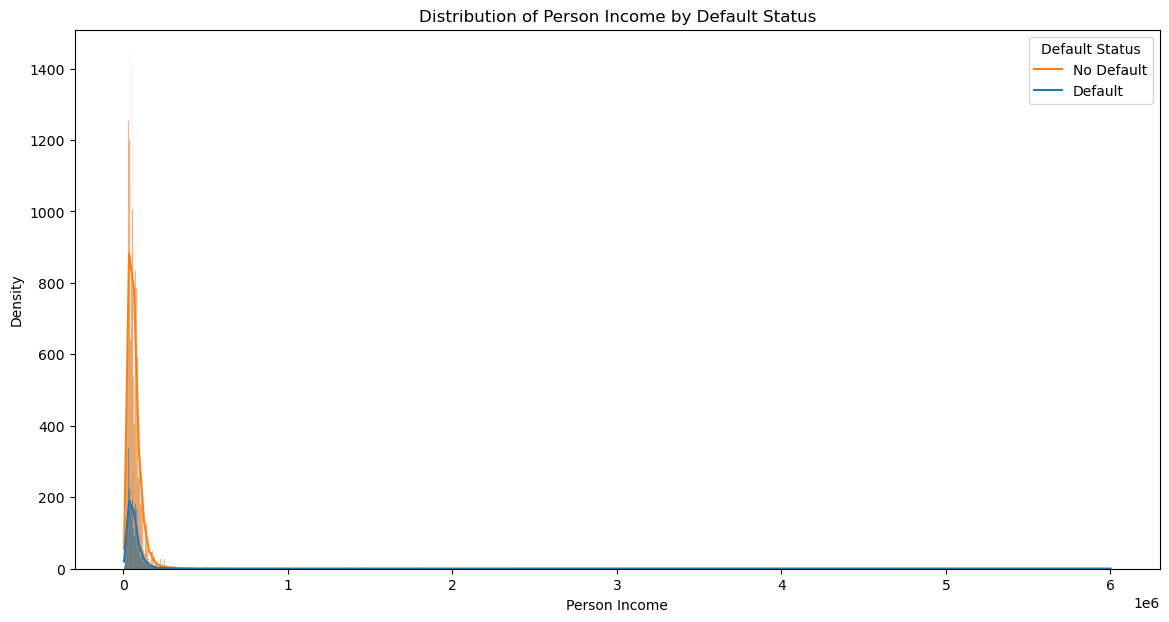

In [ ]:
#Income distribution by default status;
plt.figure(figsize=(14, 7))
sns.histplot(data=df, x='person_income', hue='cb_person_default_on_file', kde=True)
plt.title('Distribution of Person Income by Default Status')
plt.xlabel('Person Income') 
plt.ylabel('Density')
plt.legend(labels=['No Default', 'Default'], title='Default Status')
plt.show()

In [ ]:
# #calculate loan percentage of income.

df_cleaned['loan_percent_income'] = df_cleaned['loan_amnt'] / df['person_income']*100

print(df_cleaned['loan_percent_income'].describe())

  

count    31439.000000
mean        17.080699
std         10.703292
min          0.128205
25%          8.998426
50%         14.830508
75%         22.934557
max         83.000000
Name: loan_percent_income, dtype: float64


C:\Users\DELL\AppData\Local\Temp\ipykernel_11648\1317175358.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['loan_percent_income'] = df_cleaned['loan_amnt'] / df['person_income']*100


In [ ]:
# Define eligibility for Standard Card.
df['eligible_for_standard_card'] = (
    (df['cb_person_default_on_file'] == 'N') &
    (df['loan_status'] == 0) &                        # loan_status == 0 for paid loan
    (df['person_income'] >= 40000) &                   # monthly income in NPR
    (df['loan_percent_income'] < 0.4)
)

eligible_count_standard = df['eligible_for_standard_card'].value_counts(normalize=True) * 100

print(eligible_count_standard)

eligible_for_standard_card
True     53.122986
False    46.877014
Name: proportion, dtype: float64


C:\Users\DELL\AppData\Local\Temp\ipykernel_11648\4106227456.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=eligible_count_standard.index, y=eligible_count_standard.values, palette='viridis')


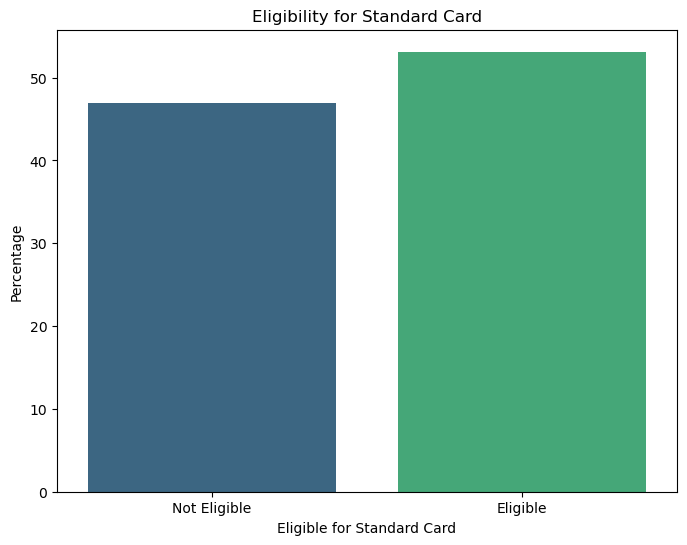

In [ ]:
plt.figure(figsize=(8, 6))
sns.barplot(x=eligible_count_standard.index, y=eligible_count_standard.values, palette='viridis')
plt.title('Eligibility for Standard Card')
plt.xlabel('Eligible for Standard Card')
plt.ylabel('Percentage')
plt.xticks([0, 1], ['Not Eligible', 'Eligible'])
plt.show()

In [ ]:
# Define eligibility for platinum Card.
df['eligible_for_platinum_card'] = (
    (df['cb_person_default_on_file'] == 'N') &
    (df['loan_status'] == 0) &                               # loan_status == 0 for paid loan
    (df['person_income'] >=133000) &                         # monthly income in NPR
    (df['loan_percent_income'] < 0.4)
)

eligible_count_platinum = df['eligible_for_platinum_card'].value_counts(normalize=True) * 100

print(eligible_count_platinum)


eligible_for_platinum_card
False    95.795095
True      4.204905
Name: proportion, dtype: float64


C:\Users\DELL\AppData\Local\Temp\ipykernel_11648\1247025447.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=eligible_count_platinum.index, y=eligible_count_platinum.values, palette='viridis')


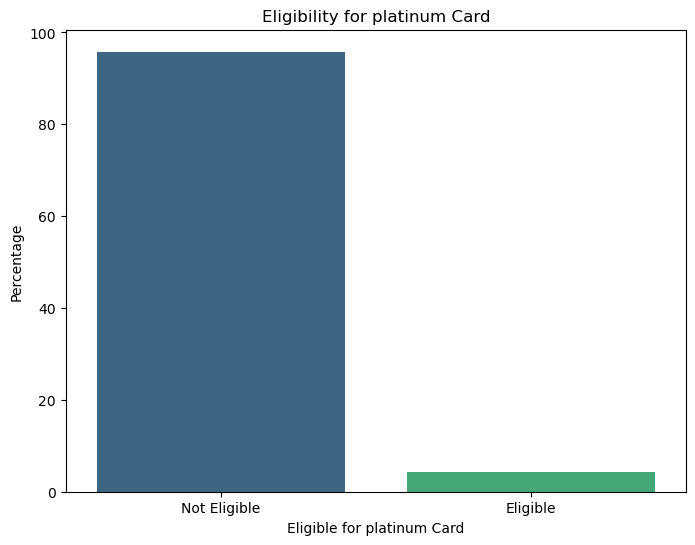

In [ ]:
plt.figure(figsize=(8, 6))
sns.barplot(x=eligible_count_platinum.index, y=eligible_count_platinum.values, palette='viridis')
plt.title('Eligibility for platinum Card')
plt.xlabel('Eligible for platinum Card')
plt.ylabel('Percentage')
plt.xticks([0, 1], ['Not Eligible', 'Eligible'])
plt.show()

`Label encoder and one hot encoder`

In [ ]:
#Label Encoding for ordinal variables
from sklearn.preprocessing import LabelEncoder

df_encoded = df_cleaned.copy()

# Variables with natural order 
label_encoder = LabelEncoder()

ordinal_vars=["loan_grade"]

for col in ordinal_vars:
 df_encoded[col] = label_encoder.fit_transform(df_encoded[col])

# One-Hot Encoding for nominal variables

nominal_vars = ["person_home_ownership", "loan_intent", "cb_person_default_on_file"]

df_encoded = pd.get_dummies(df_encoded, columns=nominal_vars, drop_first=True)

In [ ]:
df_encoded.isnull().sum()

person_age                        0
person_income                     0
person_emp_length               869
loan_grade                        0
loan_amnt                         0
loan_int_rate                  2980
loan_status                       0
loan_percent_income               0
cb_person_cred_hist_length        0
person_home_ownership_OTHER       0
person_home_ownership_OWN         0
person_home_ownership_RENT        0
loan_intent_EDUCATION             0
loan_intent_HOMEIMPROVEMENT       0
loan_intent_MEDICAL               0
loan_intent_PERSONAL              0
loan_intent_VENTURE               0
cb_person_default_on_file_Y       0
dtype: int64

In [ ]:
df_encoded = df_encoded.fillna(0)  # replaces all NaNs with 0


In [ ]:
df_encoded.columns

Index(['person_age', 'person_income', 'person_emp_length', 'loan_grade',
       'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_cred_hist_length', 'person_home_ownership_OTHER',
       'person_home_ownership_OWN', 'person_home_ownership_RENT',
       'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT',
       'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE',
       'cb_person_default_on_file_Y'],
      dtype='object')

`Model define`

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pickle

if 'loan_status' in df_encoded.columns:
    models = {
        "Logistic Regression": LogisticRegression(random_state=42),
        "Random Forest": RandomForestClassifier(random_state=42),
        "SVC": SVC(probability=True, random_state=42),
        "Gradient Boosting": GradientBoostingClassifier(random_state=42)
    }
    
    results = {}
    
    X = df_encoded.drop('loan_status', axis=1)
    y = df_encoded['loan_status']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    scaler = StandardScaler()
    
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for model_name, model in models.items():
        print(f"\n{'='*50}")
        print(f"Training {model_name}...")

        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

        accuracy = accuracy_score(y_test, y_pred)
        results[model_name] = accuracy

        print(f"{model_name} Accuracy: {accuracy:.4f}")
        print("\nConfusion Matrix:")
        print(confusion_matrix(y_test, y_pred))
        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))

    print("\nModel Performance Summary:")
    for name, acc in results.items():
        print(f"{name}: {acc:.4f}")


    # Select best model

    best_model_name = max(results, key=results.get)
    best_model = models[best_model_name]

    print(f"\nBest Model: {best_model_name} with Accuracy = {results[best_model_name]:.4f}")


    


Training Logistic Regression...
Logistic Regression Accuracy: 0.8508

Confusion Matrix:
[[4684  229]
 [ 709  666]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.95      0.91      4913
           1       0.74      0.48      0.59      1375

    accuracy                           0.85      6288
   macro avg       0.81      0.72      0.75      6288
weighted avg       0.84      0.85      0.84      6288


Training Random Forest...
Random Forest Accuracy: 0.9324

Confusion Matrix:
[[4881   32]
 [ 393  982]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      4913
           1       0.97      0.71      0.82      1375

    accuracy                           0.93      6288
   macro avg       0.95      0.85      0.89      6288
weighted avg       0.93      0.93      0.93      6288


Training SVC...
SVC Accuracy: 0.9081

Confusion Matrix:
[[4858   55]
 [ 523  

In [ ]:
import pickle

In [ ]:
# Save the best model
with open('best_model.pkl', 'wb') as file:
        pickle.dump(best_model, file)

In [ ]:
#save loan_grade_encoder:
with open("loan_grade_encoder.pkl", "rb") as f:
    loan_grade_encoder = pickle.load(f)

In [ ]:
# Save final column order after encoding
model_columns = df_encoded.drop("loan_status", axis=1).columns
with open("model_columns.pkl", "wb") as f:
    pickle.dump(model_columns.tolist(), f)
